# Multivariate Chronos-2 fine-tuning / zero-shot

This notebook replaces the original univariate Chronos-T5 setup with **Chronos-2**
(`amazon/chronos-2`), which natively supports covariates — the original notebook
explicitly excluded weather / prices / calendar / static features because the
older Chronos-T5 has no covariate support.

### What changed vs. the original

| Aspect | Original (Chronos-T5-small) | This notebook (Chronos-2) |
|---|---|---|
| Inputs | univariate target only | target + weather + prices + calendar + static |
| Tokenization | `MeanScaleUniformBins` (categorical CE on bins) | patch embeddings + quantile heads (no value tokenization) |
| Architecture | T5 seq2seq (decoder samples tokens) | encoder-only transformer with **group attention** |
| Training mode | always fine-tuned with cross-entropy | zero-shot **by default**, optional LoRA fine-tuning |
| Covariates path | excluded | passed via `predict_df(future_df=...)` |

### Covariate handling — Chronos-2 specifics

Chronos-2 supports:
- past-only and known-future covariates,
- real-valued and categorical covariates (categoricals as numpy string arrays),
- but **not** static (time-invariant) covariates.

For features like `latitude`, `longitude`, `dso_desc`, `station_type`, `oblast`
which are constant per `eic_code`, the documented workaround is to either
(a) group series sharing the static value, or (b) broadcast the static value as
a constant time-varying covariate. We use (b) — it preserves per-station
identity through the `id_column` and lets the group-attention layer pick up the
metadata signal.

Calendar columns (`Month`, `Day`, `Hour`, `day_of_week`, `season`) are
known-future numeric covariates.

`eic_code` is the `id_column` (the series identifier) and is therefore not
passed as a covariate column.


In [69]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
from typing import Dict, List, Optional, Tuple
from data_loading import *
from loss_funcs import *

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision set to 'medium'")


PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision set to 'medium'


In [70]:
# --- Feature lists (multivariate setup, exactly as requested) ----------------
weather_cols_to_keep = [
    "temperature_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "shortwave_radiation",
    "direct_normal_irradiance",
]

other_cols = [  # not static
    "dam_price", "buy_bm_price", "sell_bm_price",
    "max_power", "max_solar", "max_ev",
]

cat_columns = [
    "eic_code", "dso_desc", "station_type", "oblast",
    "Month", "Day", "Hour", "day_of_week", "season",
]

static_cols = [
    "latitude", "longitude", "eic_code", "dso_desc", "station_type", "oblast",
]

calendar_cols = [
    "Month", "Day", "Hour", "day_of_week", "season",
]

time_cols = ["datetime", "time_idx"]

# --- Routing for Chronos-2 ---------------------------------------------------
# Chronos-2 has no static-covariate slot, so static columns are broadcast as
# constant time-varying covariates (documented workaround). `eic_code` is the
# series ID and is consumed via id_column — not as a covariate.
STATIC_NUMERIC_COLS = ["latitude", "longitude"]
STATIC_CAT_COLS     = ["dso_desc", "station_type", "oblast"]

# Real-valued (numeric) covariates passed to predict_df.
# - calendar cols are integers but numeric; we keep them as floats for the model
# - all features except the categoricals are numeric
NUMERIC_COVARIATES = (
    weather_cols_to_keep
    + other_cols
    + calendar_cols
    + STATIC_NUMERIC_COLS
)

# Categorical covariates — Chronos-2 expects these as numpy string arrays.
# eic_code is excluded (it is the id_column).
CATEGORICAL_COVARIATES = STATIC_CAT_COLS  # dso_desc, station_type, oblast

ALL_COVARIATES = NUMERIC_COVARIATES + CATEGORICAL_COVARIATES

print(f"y col is        : {Y_COL}")
print(f"group col is    : {GROUP_COL}")
print(f"#numeric covars : {len(NUMERIC_COVARIATES)}")
print(f"#cat   covars   : {len(CATEGORICAL_COVARIATES)}")
print(f"covariates      : {ALL_COVARIATES}")


y col is        : sum_of_kWh
group col is    : eic_code
#numeric covars : 19
#cat   covars   : 3
covariates      : ['temperature_2m', 'precipitation', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation', 'direct_normal_irradiance', 'dam_price', 'buy_bm_price', 'sell_bm_price', 'max_power', 'max_solar', 'max_ev', 'Month', 'Day', 'Hour', 'day_of_week', 'season', 'latitude', 'longitude', 'dso_desc', 'station_type', 'oblast']


In [71]:
# --- Load data ---------------------------------------------------------------
# Same loader as before. The "with-datetime" variant keeps categoricals as raw
# strings, which is what Chronos-2 wants for categorical covariates.
print("Loading train ...")
train = load_and_prepare(TRAIN_PATH_WITH_DATETME)

print("Loading val   ...")
val = load_and_prepare(VAL_PATH_WITH_DATETME)

print("Loading test  ...")
test = load_and_prepare(TEST_PATH_WITH_DATETME)

print(f"train: {train.shape}")
print(f"val  : {val.shape}")
print(f"test : {test.shape}")


Loading train ...
Loading val   ...
Loading test  ...
train: (4586151, 38)
val  : (293880, 38)
test : (295430, 38)


In [72]:
# Optional: subsample stations if training takes too long. Same logic as before.
TARGET_STATIONS = 395

station_stats = (
    train.groupby(GROUP_COL)
    .agg(rows=(Y_COL, "count"))
    .reset_index()
    .sort_values("rows", ascending=False)
)

sampled_stations = station_stats.sample(
    n=TARGET_STATIONS, random_state=42
)[GROUP_COL].values

print(f"Stations: {len(sampled_stations)}")

train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
val   = val[val[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
test  = test[test[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)

print(f"Train rows : {len(train):,}")
print(f"Val rows   : {len(val):,}")
print(f"Test rows  : {len(test):,}")


Stations: 395
Train rows : 4,586,151
Val rows   : 293,880
Test rows  : 295,430


In [73]:
training_cutoff = train["time_idx"].max()
val_cutoff      = val["time_idx"].max()
test_cutoff     = test["time_idx"].max()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")


training cutoff : 13125
val cutoff      : 13869
test cutoff     : 14617


## Chronos-2 setup

We use the official `chronos-forecasting>=2.1.0` package, which exposes
`Chronos2Pipeline`. The pipeline accepts long-format DataFrames with
`id_column`, `timestamp_column`, `target` and any number of additional covariate
columns.

### Important Chronos-2 specifics
1. **Zero-shot by default** — Chronos-2 is pretrained for zero-shot inference and
   often outperforms fine-tuning with limited data. We run zero-shot first; a
   LoRA fine-tune cell is provided as an opt-in.
2. **Categorical covariates** are detected by dtype: pandas `object`/`string`
   columns are treated as categorical. We make sure those columns are real
   strings (not pandas `Categorical` codes).
3. **Static features** are broadcast as constant time-varying covariates.
4. **Rolling inference** is preserved at chunks of `PREDICTION_LEN` (default 64)
   so that we mirror the original notebook's teacher-forced operational protocol
   (yesterday's actuals + today's known covariates → today's forecast).
5. **No bin-tokenizer / no CE loss** — Chronos-2 outputs quantiles directly via
   the patch-quantile head. We still evaluate with `money_pct` and friends for
   model selection, exactly as before.


In [74]:
# One-time install. Requires chronos-forecasting >= 2.1.0 for stable predict_df
# and covariate support.
# !pip install -q --upgrade 'chronos-forecasting>=2.1.0' 'pandas[pyarrow]' mlflow tqdm


In [75]:
# --- Chronos-2 / utility imports --------------------------------------------
import os
import math
import json
import random
import tempfile
from pathlib import Path

import mlflow
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm.notebook import tqdm

from chronos import Chronos2Pipeline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


In [76]:
# --- Hyperparameters ---------------------------------------------------------
MODEL_ID         = "amazon/chronos-2"

# Chronos-2 supports up to 8192 context length. We mirror the original notebook
# at 512 — long enough to capture multi-day weekly patterns, fast for batched
# rolling inference. Bump if your sequences and GPU allow.
CONTEXT_LEN      = 512
PREDICTION_LEN   = 64    # rolling chunk; same horizon protocol as the original

# Inference-time settings
QUANTILE_LEVELS  = [0.1, 0.5, 0.9]   # 0.5 (median) is used as the point forecast
INFERENCE_BATCH_SIZE = 16            # how many series to forecast per pipeline call

# Optional LoRA fine-tuning (zero-shot first; flip this if zero-shot is not enough)
DO_FINETUNE      = True
FT_NUM_STEPS     = 1500   # was 1000
FT_BATCH_SIZE    = 16      # was 8 — increase if VRAM allows
FT_LR            = 1e-4    # was 1e-4 — LoRA usually wants higher LR than full FT
FT_CONTEXT_LEN   = CONTEXT_LEN

SEED             = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


## Build long-format DataFrames for Chronos-2

`predict_df` consumes long-format DataFrames where each row is one
(item_id, timestamp) observation. We need three things:

- `context_df` — the **history** for each station: target + past values of all
  covariates. For val: history = train. For test: history = train + val.
- `future_df`  — the **forecast horizon**: known-future values of all covariates
  (no target). Calendar / weather / prices / static metadata are all known at
  forecast time, so this is straightforward.
- We do this **per chunk** during rolling inference so each chunk only sees
  the appropriate context window.


In [77]:
# --- Common dataframe prep helpers ------------------------------------------

REQUIRED_COLS_FOR_CHRONOS = [GROUP_COL, "datetime", Y_COL] + ALL_COVARIATES

# Some splits may carry tz-aware datetimes; Chronos-2 needs a naive timestamp
# column with a regular frequency. We standardise here.

def _to_chronos_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of df with the columns Chronos-2 needs and the right dtypes.

    - datetime  -> tz-naive pandas Timestamp
    - numeric covariates -> float32
    - categorical covariates -> string (object dtype)
    """
    out = df[[GROUP_COL, "datetime", Y_COL, "time_idx"] + ALL_COVARIATES].copy()
    # Strip timezone so freq inference is unambiguous
    if pd.api.types.is_datetime64tz_dtype(out["datetime"]):
        out["datetime"] = out["datetime"].dt.tz_localize(None)

    for c in NUMERIC_COVARIATES:
        out[c] = pd.to_numeric(out[c], errors="coerce").astype(np.float32)

    for c in CATEGORICAL_COVARIATES:
        # Make sure these are real strings (not pandas Categorical) — Chronos-2's
        # df_utils detects categoricals by `object`/`string` dtype.
        out[c] = out[c].astype(str)

    out[Y_COL] = out[Y_COL].astype(np.float32)
    return out


print("Materialising Chronos-2 frames ...")
train_chronos = _to_chronos_frame(train).sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)
val_chronos   = _to_chronos_frame(val).sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)
test_chronos  = _to_chronos_frame(test).sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)

print(f"train_chronos: {train_chronos.shape}")
print(f"val_chronos  : {val_chronos.shape}")
print(f"test_chronos : {test_chronos.shape}")
print(f"dtypes (sample):")
print(train_chronos[ALL_COVARIATES + [Y_COL]].dtypes.value_counts())


Materialising Chronos-2 frames ...
train_chronos: (4586151, 26)
val_chronos  : (293880, 26)
test_chronos : (295430, 26)
dtypes (sample):
float32    20
str         3
Name: count, dtype: int64


In [78]:
# Quick sanity check: pick one station and inspect what the long-format frame
# looks like. This is exactly the row layout predict_df expects.

_any_code = train_chronos[GROUP_COL].iloc[0]
_preview = train_chronos[train_chronos[GROUP_COL] == _any_code].head(3)
print(f"Preview for station {_any_code}:")
print(_preview[[GROUP_COL, "datetime", Y_COL,
                "temperature_2m", "shortwave_radiation",
                "dam_price", "Hour", "season",
                "latitude", "dso_desc", "station_type", "oblast"]].to_string(index=False))


Preview for station 62Z0008583037334:
        eic_code            datetime  sum_of_kWh  temperature_2m  shortwave_radiation  dam_price  Hour  season  latitude dso_desc  station_type       oblast
62Z0008583037334 2024-01-01 01:00:00   24.043646             5.3                  0.0  57.000000   1.0     1.0 48.442429  Ужгород ОККО-комплекс Закарпатська
62Z0008583037334 2024-01-01 02:00:00   22.768120             5.1                  0.0  55.549999   2.0     1.0 48.442429  Ужгород ОККО-комплекс Закарпатська
62Z0008583037334 2024-01-01 03:00:00   21.620148             5.2                  0.0  38.000000   3.0     1.0 48.442429  Ужгород ОККО-комплекс Закарпатська


In [79]:
# --- Load the Chronos-2 pipeline --------------------------------------------
# Default dtype is bfloat16 on Ampere+ GPUs (3090). Chronos-2 supports both
# CPU and GPU inference; we use GPU.

torch.backends.cudnn.benchmark = True

pipeline = Chronos2Pipeline.from_pretrained(
    MODEL_ID,
    device_map=DEVICE,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)
print(f"Loaded {MODEL_ID}")
print(f"  model_prediction_length = {pipeline.model_prediction_length}")
print(f"  context length supported up to 8192")


Loaded amazon/chronos-2
  model_prediction_length = 1024
  context length supported up to 8192


## Optional: LoRA fine-tuning

Chronos-2 is zero-shot and the recommendation in the official docs is
*"zero-shot first, then fine-tune"*. This cell is gated behind `DO_FINETUNE`
(default `False`). Enable it only after you have a zero-shot baseline.

The default LoRA config targets the attention `q/k/v/o` and the
`output_patch_embedding.output_layer`, which is the recipe used in AutoGluon.


In [80]:
# --- Long-format DataFrame -> Chronos-2 fit() inputs -------------------------
# Chronos2Pipeline.fit expects an iterable of per-series dicts whose allowed
# keys are EXACTLY: {"target", "past_covariates", "future_covariates"}.
#
# Convention (confirmed from chronos-forecasting source + AutoGluon adapter):
#   - "target": np.ndarray of shape (T,) — the y values, full length.
#   - "past_covariates": {name -> np.ndarray of shape (T,)} — the FULL series
#     for every covariate, past + future combined. The trainer slices windows
#     internally; you give it the whole thing.
#   - "future_covariates": {name -> np.ndarray} — a *marker* dict listing which
#     covariates are known in the future. Values can be empty arrays; their
#     presence flags the column as known-future, the actual numbers are read
#     from past_covariates (which already span the future window).
# Categorical covariates -> numpy string arrays (dtype.kind == 'U').
# Numeric covariates    -> float32.

def _series_dict_from_group(g: pd.DataFrame) -> dict:
    g = g.sort_values("time_idx")
    target = g[Y_COL].to_numpy(dtype=np.float32)

    past_covariates = {}
    for c in NUMERIC_COVARIATES:
        past_covariates[c] = g[c].to_numpy(dtype=np.float32)
    for c in CATEGORICAL_COVARIATES:
        past_covariates[c] = g[c].astype(str).to_numpy()

    # All our covariates (weather/prices/calendar/static) are known at
    # forecast time. Mark them via empty-array entries in future_covariates.
    future_covariates = {name: np.array([]) for name in past_covariates.keys()}

    return {
        "target": target,
        "past_covariates": past_covariates,
        "future_covariates": future_covariates,
    }


def build_fit_inputs(df: pd.DataFrame) -> list:
    out = []
    for _, g in df.groupby(GROUP_COL, sort=False):
        if len(g) < CONTEXT_LEN + PREDICTION_LEN:
            continue
        out.append(_series_dict_from_group(g))
    return out


print("Building fit() inputs ...")
fit_inputs = build_fit_inputs(train_chronos)
print(f"  #series usable for fine-tuning: {len(fit_inputs)}")
print(f"  example keys: {list(fit_inputs[0].keys())}")
print(f"  example target shape: {fit_inputs[0]['target'].shape}")
print(f"  example #past covariates  : {len(fit_inputs[0]['past_covariates'])}")
print(f"  example #future markers   : {len(fit_inputs[0]['future_covariates'])}")

Building fit() inputs ...
  #series usable for fine-tuning: 395
  example keys: ['target', 'past_covariates', 'future_covariates']
  example target shape: (13126,)
  example #past covariates  : 22
  example #future markers   : 22


In [81]:
from peft import LoraConfig

LORA_CONFIG = LoraConfig(
    r=32,                     # was effectively 8 in defaults
    lora_alpha=64,            # typically 2 * r
    lora_dropout=0.05,
    target_modules=[
        "self_attention.q",
        "self_attention.k",
        "self_attention.v",
        "self_attention.o",
        "output_patch_embedding.output_layer",
    ],
    bias="none",
)

In [82]:
if DO_FINETUNE:
    print("Fine-tuning Chronos-2 with LoRA ...")
    val_fit_inputs = build_fit_inputs(val_chronos)[:32]   # ~32 series is enough

    pipeline = pipeline.fit(
        inputs=fit_inputs,
        validation_inputs=val_fit_inputs,
        prediction_length=PREDICTION_LEN,
        finetune_mode="lora",
        lora_config=LORA_CONFIG,
        learning_rate=FT_LR,
        num_steps=FT_NUM_STEPS,
        batch_size=FT_BATCH_SIZE,
        context_length=FT_CONTEXT_LEN,
    )
    print("LoRA fine-tune complete.")
else:
    print("Skipping fine-tuning (DO_FINETUNE=False) — using zero-shot pretrained model.")

Fine-tuning Chronos-2 with LoRA ...


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss,Validation Loss
100,0.215600,0.162706
200,0.202600,0.133341
300,0.194200,0.216277
400,0.195400,0.136971
500,0.191300,0.137982
600,0.174200,0.144168
700,0.178300,0.128168
800,0.164900,0.122520
900,0.163100,0.116065
1000,0.148900,0.135237


LoRA fine-tune complete.


## Rolling multivariate inference

We mirror the original notebook's teacher-forced rolling protocol:

1. For each station, take the last `CONTEXT_LEN` observed targets (+ matching
   covariates) as `context_df`.
2. Take the next `PREDICTION_LEN` rows of covariates (no target) as `future_df`.
3. Predict that chunk — keep the median (q=0.5) as the point forecast.
4. Append the chunk's **true** actuals (and their covariates) to the context
   and slide forward by `PREDICTION_LEN`.
5. Repeat until the full eval horizon is covered.

To keep GPU utilisation high, we batch many stations together inside each
chunk: `predict_df` accepts arbitrarily many `item_id`s in one call, and
Chronos-2 forecasts them in parallel.


In [83]:
# --- Build per-station chronological history once, then slide a window ------
# We store everything as a single long DataFrame keyed by (item_id, time_idx)
# and use boolean masks for fast windowing during rolling inference.

def split_history(df: pd.DataFrame, codes: List[str]) -> Dict[str, pd.DataFrame]:
    """Return {code -> chronologically-sorted slice of df for that code}."""
    out = {}
    for code, g in df[df[GROUP_COL].isin(codes)].groupby(GROUP_COL, sort=False):
        out[code] = g.sort_values("time_idx").reset_index(drop=True)
    return out


eval_codes = sorted(set(val_chronos[GROUP_COL].unique()) | set(test_chronos[GROUP_COL].unique()))

train_hist_by_code = split_history(train_chronos, eval_codes)
val_hist_by_code   = split_history(val_chronos,   eval_codes)
test_hist_by_code  = split_history(test_chronos,  eval_codes)

# Drop stations whose train history is shorter than CONTEXT_LEN — Chronos-2 can
# handle short context but the rolling protocol needs at least one full window.
usable_codes = [c for c in eval_codes
                if c in train_hist_by_code and len(train_hist_by_code[c]) >= CONTEXT_LEN]
print(f"#usable stations: {len(usable_codes)} / {len(eval_codes)}")


#usable stations: 395 / 395


In [84]:
# --- Chunk-level batched rolling inference ----------------------------------
# Strategy: at each rolling step, build one long-format `context_df` and one
# `future_df` for ALL stations together, then call pipeline.predict_df once.
#
# Important: stations may have slightly different horizon lengths (e.g. test
# horizon is 745h for some stations and 744h for others), so on the final
# rolling chunk the per-station tail length may differ. predict_df requires
# all series in a single call to share the same prediction_length, so we
# group active stations by their remaining-tail length and issue one call per
# length-group. In practice this only matters on the very last chunk.

CHRONOS_ID_COL  = "item_id"
CHRONOS_TS_COL  = "timestamp"
CHRONOS_TGT_COL = "target"


def _rename_for_chronos(df: pd.DataFrame, drop_target: bool = False) -> pd.DataFrame:
    cols = {GROUP_COL: CHRONOS_ID_COL, "datetime": CHRONOS_TS_COL, Y_COL: CHRONOS_TGT_COL}
    out = df.rename(columns=cols)
    if drop_target and CHRONOS_TGT_COL in out.columns:
        out = out.drop(columns=[CHRONOS_TGT_COL])
    keep = [CHRONOS_ID_COL, CHRONOS_TS_COL] + ALL_COVARIATES
    if not drop_target:
        keep.insert(2, CHRONOS_TGT_COL)
    return out[keep]


def _resolve_median_col(pred_df: pd.DataFrame):
    """predict_df returns quantile columns; the column name for q=0.5 may be
    a string '0.5', a float 0.5, or pandas may have coerced it. Find it."""
    for cand in pred_df.columns:
        if str(cand) == "0.5":
            return cand
    raise KeyError(f"Could not find median (0.5) column in predict_df output. "
                   f"Got columns: {list(pred_df.columns)}")


def rolling_predict_split(
    pipeline: Chronos2Pipeline,
    horizon_df: pd.DataFrame,             # the val or test split (long format)
    history_by_code: Dict[str, pd.DataFrame],  # base history per station (e.g. train, or train+val)
    codes: List[str],
    chunk: int = PREDICTION_LEN,
    context_len: int = CONTEXT_LEN,
    desc: str = "rolling",
) -> pd.DataFrame:
    """Roll Chronos-2 across the full eval horizon and return predictions.

    Returns a DataFrame with columns: [GROUP_COL, datetime, time_idx, Y_COL,
    dam_price, sell_bm_price, buy_bm_price, pred].
    """
    # Pre-sort the eval split by (code, time_idx) and slice once per code
    horizon_by_code = {
        c: g.sort_values("time_idx").reset_index(drop=True)
        for c, g in horizon_df[horizon_df[GROUP_COL].isin(codes)].groupby(GROUP_COL, sort=False)
    }

    # Working copy of history per code; we extend with revealed actuals as we roll
    work_hist = {c: history_by_code[c].copy() for c in codes if c in history_by_code}

    # Per-station horizon length and global max — drives chunk count
    horizon_lens = {c: len(g) for c, g in horizon_by_code.items()}
    if not horizon_lens:
        return pd.DataFrame(columns=[GROUP_COL, "datetime", "time_idx", Y_COL,
                                     "dam_price", "sell_bm_price", "buy_bm_price", "pred"])
    H = max(horizon_lens.values())
    n_chunks = math.ceil(H / chunk)
    pbar = tqdm(total=n_chunks, desc=desc)

    out_rows = []
    cursor = 0
    while cursor < H:
        # Group active stations by their remaining-tail length so each predict_df
        # call sees a uniform prediction_length.
        by_steps: Dict[int, List[str]] = {}
        for c in codes:
            if c not in work_hist or c not in horizon_by_code:
                continue
            remaining = horizon_lens[c] - cursor
            if remaining <= 0:
                continue
            steps = min(chunk, remaining)
            by_steps.setdefault(steps, []).append(c)

        if not by_steps:
            break

        for steps, group_codes in by_steps.items():
            # Build context + future frames for this length-bucket
            ctx_frames, fut_frames = [], []
            for c in group_codes:
                full_hist = work_hist[c]
                future_slice = horizon_by_code[c].iloc[cursor : cursor + steps]
                ctx = full_hist.tail(context_len)
                ctx_frames.append(ctx)
                fut_frames.append(future_slice)

            ctx_df = pd.concat(ctx_frames, ignore_index=True)
            fut_df = pd.concat(fut_frames, ignore_index=True)

            ctx_long = _rename_for_chronos(ctx_df, drop_target=False)
            fut_long = _rename_for_chronos(fut_df, drop_target=True)

            # Run Chronos-2 in batches of stations within this length-bucket.
            forecast_chunks = []
            for i in range(0, len(group_codes), INFERENCE_BATCH_SIZE):
                batch_ids = group_codes[i : i + INFERENCE_BATCH_SIZE]
                ctx_b = ctx_long[ctx_long[CHRONOS_ID_COL].isin(batch_ids)]
                fut_b = fut_long[fut_long[CHRONOS_ID_COL].isin(batch_ids)]
                pred_b = pipeline.predict_df(
                    ctx_b,
                    future_df=fut_b,
                    prediction_length=steps,
                    quantile_levels=QUANTILE_LEVELS,
                    id_column=CHRONOS_ID_COL,
                    timestamp_column=CHRONOS_TS_COL,
                    target=CHRONOS_TGT_COL,
                )
                forecast_chunks.append(pred_b)
            pred_df = pd.concat(forecast_chunks, ignore_index=True)

            # Resolve the median column and rename for joining.
            median_col = _resolve_median_col(pred_df)
            pred_df = pred_df.rename(columns={CHRONOS_ID_COL: GROUP_COL,
                                              CHRONOS_TS_COL: "datetime",
                                              median_col: "pred"})

            # Join predictions back to the horizon slice (by (code, datetime))
            merged = (
                fut_df[[GROUP_COL, "datetime", "time_idx", "dam_price",
                        "sell_bm_price", "buy_bm_price"]]
                .merge(
                    horizon_df[[GROUP_COL, "datetime", Y_COL]],
                    on=[GROUP_COL, "datetime"],
                    how="left",
                )
                .merge(
                    pred_df[[GROUP_COL, "datetime", "pred"]],
                    on=[GROUP_COL, "datetime"],
                    how="left",
                )
            )
            out_rows.append(merged)

            # Append the *true* horizon slice to each station's history (rolling
            # teacher-forcing) so the next chunk sees yesterday's real values.
            for c in group_codes:
                new_obs = horizon_by_code[c].iloc[cursor : cursor + steps]
                work_hist[c] = pd.concat([work_hist[c], new_obs], ignore_index=True)

        cursor += chunk
        pbar.update(1)

    pbar.close()
    if not out_rows:
        return pd.DataFrame(columns=[GROUP_COL, "datetime", "time_idx", Y_COL,
                                     "dam_price", "sell_bm_price", "buy_bm_price", "pred"])
    return pd.concat(out_rows, ignore_index=True).sort_values([GROUP_COL, "datetime"]).reset_index(drop=True)


## Quick validation hook

Same idea as the original notebook's `quick_val_money_pct`: forecast a small
sample of stations one chunk into the future to get a fast proxy of the full
`money_pct`. Useful if you enable LoRA fine-tuning and want a per-step monitor.
For pure zero-shot we run it once for sanity.


In [85]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values


VAL_QUICK_STATIONS = 16
_quick_codes = random.sample(usable_codes, min(VAL_QUICK_STATIONS, len(usable_codes)))


def quick_val_money_pct() -> float:
    """One-chunk-per-station rolling on a sample — fast proxy of full money_pct."""
    quick_eval = rolling_predict_split(
        pipeline=pipeline,
        horizon_df=val_chronos,
        history_by_code=train_hist_by_code,
        codes=_quick_codes,
        chunk=PREDICTION_LEN,
        context_len=CONTEXT_LEN,
        desc="quick val",
    )
    quick_eval = quick_eval.dropna(subset=["pred", Y_COL])
    if quick_eval.empty:
        return float("nan")
    return money_pct(quick_eval[Y_COL], quick_eval["pred"], *_prices(quick_eval))


print(f"Quick val money_pct on {len(_quick_codes)} stations:")
qv = quick_val_money_pct()
print(f"  money_pct = {qv:.4f}")


Quick val money_pct on 16 stations:


quick val:   0%|          | 0/12 [00:00<?, ?it/s]

  money_pct = 1.5254


## Full rolling evaluation on val and test


In [86]:
# Build histories the same way the original notebook did:
# - val:  history = train
# - test: history = train + val (concatenated per station)

train_plus_val_by_code: Dict[str, pd.DataFrame] = {}
for c in usable_codes:
    parts = []
    if c in train_hist_by_code: parts.append(train_hist_by_code[c])
    if c in val_hist_by_code:   parts.append(val_hist_by_code[c])
    if parts:
        train_plus_val_by_code[c] = pd.concat(parts, ignore_index=True).sort_values("time_idx").reset_index(drop=True)


val_eval = rolling_predict_split(
    pipeline=pipeline,
    horizon_df=val_chronos,
    history_by_code=train_hist_by_code,
    codes=usable_codes,
    chunk=PREDICTION_LEN,
    context_len=CONTEXT_LEN,
    desc="val rolling",
)

test_eval = rolling_predict_split(
    pipeline=pipeline,
    horizon_df=test_chronos,
    history_by_code=train_plus_val_by_code,
    codes=usable_codes,
    chunk=PREDICTION_LEN,
    context_len=CONTEXT_LEN,
    desc="test rolling",
)

print(f"val_eval shape  : {val_eval.shape}")
print(f"test_eval shape : {test_eval.shape}")
val_eval.head()


val rolling:   0%|          | 0/12 [00:00<?, ?it/s]

test rolling:   0%|          | 0/12 [00:00<?, ?it/s]

val_eval shape  : (293880, 8)
test_eval shape : (295430, 8)


,eic_code,datetime,time_idx,dam_price,sell_bm_price,buy_bm_price,sum_of_kWh,pred
0,62Z0008583037334,2025-07-01 00:00:00,13126,5568.520020,0.01,5846.950195,21.0,21.6250
1,62Z0008583037334,2025-07-01 01:00:00,13127,5568.419922,0.01,5846.839844,19.0,19.0000
2,62Z0008583037334,2025-07-01 02:00:00,13128,5190.000000,0.01,5449.500000,16.0,16.5000
3,62Z0008583037334,2025-07-01 03:00:00,13129,4888.000000,0.01,5132.399902,16.0,15.5000
4,62Z0008583037334,2025-07-01 04:00:00,13130,4299.000000,0.01,4513.950195,15.0,14.5625


In [87]:
# --- Aggregate metrics on val and test --------------------------------------

# Drop any rows where merge failed (defensive — shouldn't happen in normal runs)
val_eval = val_eval.dropna(subset=["pred", Y_COL]).reset_index(drop=True)
test_eval = test_eval.dropna(subset=["pred", Y_COL]).reset_index(drop=True)

val_smape_v     = smape(val_eval[Y_COL], val_eval["pred"])
val_rmse_v      = rmse(val_eval[Y_COL], val_eval["pred"])
val_mape_v      = mape(val_eval[Y_COL], val_eval["pred"])
val_money_v     = money(val_eval[Y_COL], val_eval["pred"], *_prices(val_eval))
val_money_pct_v = money_pct(val_eval[Y_COL], val_eval["pred"], *_prices(val_eval))

test_smape_v     = smape(test_eval[Y_COL], test_eval["pred"])
test_rmse_v      = rmse(test_eval[Y_COL], test_eval["pred"])
test_mape_v      = mape(test_eval[Y_COL], test_eval["pred"])
test_money_v     = money(test_eval[Y_COL], test_eval["pred"], *_prices(test_eval))
test_money_pct_v = money_pct(test_eval[Y_COL], test_eval["pred"], *_prices(test_eval))

val_mae_v   = float(np.mean(np.abs(val_eval[Y_COL].values  - val_eval["pred"].values)))
test_mae_v  = float(np.mean(np.abs(test_eval[Y_COL].values - test_eval["pred"].values)))
val_bias_v  = float(val_eval["pred"].sum()  - val_eval[Y_COL].sum())
test_bias_v = float(test_eval["pred"].sum() - test_eval[Y_COL].sum())

print("── Validation ──────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE     : {val_smape_v:.4f}")
print(f"RMSE      : {val_rmse_v:.4f}")
print(f"MAE       : {val_mae_v:.4f}")
print(f"MAPE      : {val_mape_v:.2f} %")
print(f"MONEY     : {val_money_v:.4f}")
print(f"MONEY_PCT : {val_money_pct_v:.4f}%")
print(f"BIAS (pred_sum - actual_sum) : {val_bias_v:,.2f}")

print("── Test ──────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE     : {test_smape_v:.4f}")
print(f"RMSE      : {test_rmse_v:.4f}")
print(f"MAE       : {test_mae_v:.4f}")
print(f"MAPE      : {test_mape_v:.2f} %")
print(f"MONEY     : {test_money_v:.4f}")
print(f"MONEY_PCT : {test_money_pct_v:.4f}%")
print(f"BIAS (pred_sum - actual_sum) : {test_bias_v:,.2f}")


── Validation ──────────────────────────────
Aligned samples : 293,880
SMAPE     : 5.9375
RMSE      : 5.6489
MAE       : 1.3452
MAPE      : 8.03 %
MONEY     : 809259.8419
MONEY_PCT : 2.7682%
BIAS (pred_sum - actual_sum) : -56,885.00
── Test ──────────────────────────────────
Aligned samples : 295,430
SMAPE     : 5.8066
RMSE      : 6.3702
MAE       : 1.3602
MAPE      : 9.50 %
MONEY     : 1099343.1968
MONEY_PCT : 3.7201%
BIAS (pred_sum - actual_sum) : 10,946.50


In [88]:
# --- MLflow logging ---------------------------------------------------------
mlflow.set_experiment("chronos2_multivariate_electricity")
mlflow.start_run(run_name=f"chronos-2-mv-ctx{CONTEXT_LEN}-pred{PREDICTION_LEN}"
                          f"-{'lora' if DO_FINETUNE else 'zeroshot'}")

mlflow.log_params({
    "model_id":              MODEL_ID,
    "mode":                  "lora_finetune" if DO_FINETUNE else "zero_shot",
    "context_len":           CONTEXT_LEN,
    "prediction_len":        PREDICTION_LEN,
    "quantile_levels":       str(QUANTILE_LEVELS),
    "inference_batch_size":  INFERENCE_BATCH_SIZE,
    "ft_num_steps":          FT_NUM_STEPS if DO_FINETUNE else None,
    "ft_lr":                 FT_LR if DO_FINETUNE else None,
    "ft_batch_size":         FT_BATCH_SIZE if DO_FINETUNE else None,
    "n_train_stations":      len(usable_codes),
    "n_train_rows":          len(train),
    "n_val_rows":            len(val),
    "n_test_rows":           len(test),
    "train_date_min":        str(train["datetime"].min()),
    "train_date_max":        str(train["datetime"].max()),
    "val_date_min":          str(val["datetime"].min()),
    "val_date_max":          str(val["datetime"].max()),
    "test_date_min":         str(test["datetime"].min()),
    "test_date_max":         str(test["datetime"].max()),
    "n_numeric_covariates":  len(NUMERIC_COVARIATES),
    "n_cat_covariates":      len(CATEGORICAL_COVARIATES),
    "numeric_covariates":    ",".join(NUMERIC_COVARIATES),
    "categorical_covariates": ",".join(CATEGORICAL_COVARIATES),
    "loss_eval":             "money_pct (selection metric) + money, MAE, RMSE, MAPE, SMAPE",
    "static_handling":       "broadcast as constant time-varying covariates (Chronos-2 has no static slot)",
})

mlflow.log_metrics({
    "val_smape":      val_smape_v,
    "val_rmse":       val_rmse_v,
    "val_mae":        val_mae_v,
    "val_mape":       val_mape_v,
    "val_money":      val_money_v,
    "val_money_pct":  val_money_pct_v,
    "val_bias":       val_bias_v,
    "test_smape":     test_smape_v,
    "test_rmse":      test_rmse_v,
    "test_mae":       test_mae_v,
    "test_mape":      test_mape_v,
    "test_money":     test_money_v,
    "test_money_pct": test_money_pct_v,
    "test_bias":      test_bias_v,
})

# Persist predictions as artifacts
art_dir = Path(tempfile.mkdtemp(prefix="chronos2_artifacts_"))
val_eval.to_parquet(art_dir / "val_predictions.parquet")
test_eval.to_parquet(art_dir / "test_predictions.parquet")
mlflow.log_artifact(art_dir / "val_predictions.parquet")
mlflow.log_artifact(art_dir / "test_predictions.parquet")

# If we fine-tuned, save the LoRA weights too
if DO_FINETUNE:
    ckpt_dir = Path(tempfile.mkdtemp(prefix="chronos2_ckpt_"))
    pipeline.save_pretrained(str(ckpt_dir))
    mlflow.log_artifacts(str(ckpt_dir), artifact_path="finetuned_checkpoint")

mlflow.end_run()
print(f"MLflow run logged → {mlflow.get_tracking_uri()}")


MLflow run logged → file:///C:/Users/Lev/Documents/GitHub/Diploma/train_models_v2/mlruns


## Per-station diagnostics


In [89]:
def per_station_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for grp, gdf in eval_df.groupby(GROUP_COL):
        rows.append({
            GROUP_COL:    grp,
            "n":          len(gdf),
            "SMAPE":      smape(gdf[Y_COL], gdf["pred"]),
            "RMSE":       rmse (gdf[Y_COL], gdf["pred"]),
            "MAPE":       mape (gdf[Y_COL], gdf["pred"]),
            "MONEY":      money    (gdf[Y_COL], gdf["pred"], *_prices(gdf)),
            "MONEY_PCT":  money_pct(gdf[Y_COL], gdf["pred"], *_prices(gdf)),
        })
    return pd.DataFrame(rows).sort_values("SMAPE")


test_station_metrics = per_station_metrics(test_eval)

print("Top-10 best stations (test SMAPE):")
print(test_station_metrics.head(10).to_string(index=False))
print("\nBottom-10 worst stations (test SMAPE):")
print(test_station_metrics.tail(10).to_string(index=False))


Top-10 best stations (test SMAPE):
        eic_code   n    SMAPE     RMSE     MAPE       MONEY  MONEY_PCT
62Z6969613150684 748 1.796411 0.888310 1.792302 1438.064394   0.959881
62Z2673921373211 748 1.973550 1.315291 1.979695 1981.950029   1.033701
62Z9191598698031 748 2.045342 1.836622 2.054837 2700.686967   1.066217
62Z4026142936382 748 2.116177 1.073040 2.128646 1551.336576   1.098896
62Z9572466865833 748 2.121899 1.932664 2.106814 3016.038971   1.109330
62Z6605113197287 748 2.753629 2.087346 2.742047 3215.894911   1.433323
62Z8461462561806 748 2.798700 1.702880 2.794866 2714.670751   1.507936
62Z713390564870T 748 2.857621 1.989382 2.856332 3138.109515   1.533608
62Z1931450722959 748 2.949355 1.280182 2.956315 2189.830045   1.653517
62Z1774668832410 748 2.954034 2.589209 2.957925 3648.170191   1.480152

Bottom-10 worst stations (test SMAPE):
        eic_code   n     SMAPE      RMSE        MAPE         MONEY  MONEY_PCT
62Z945209821808O 748 22.071692 18.429021   24.527325  22741.164866

Best  station (SMAPE): 62Z6969613150684


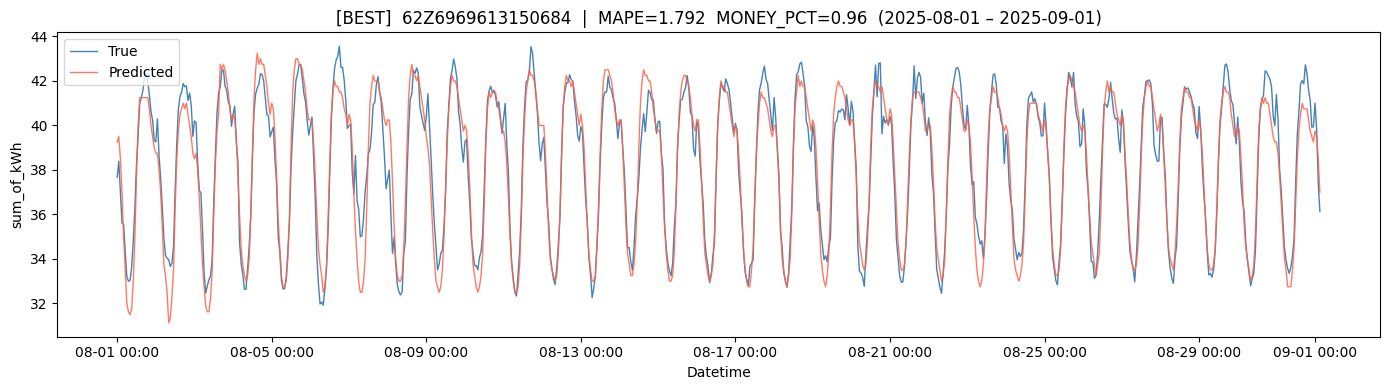

Worst station (SMAPE): 62Z0101426517156


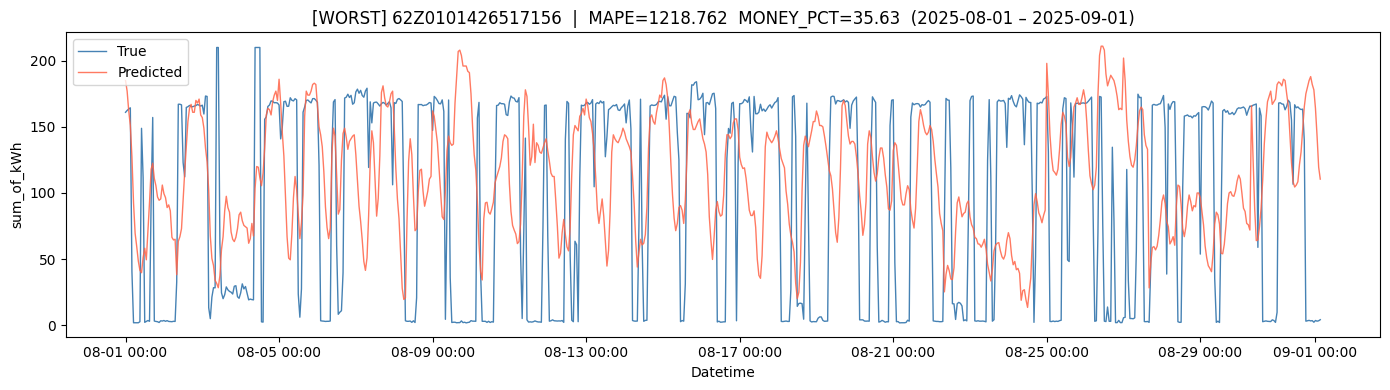

In [90]:
def plot_forecast(df, eic_code, start_dt=None, end_dt=None, title_prefix=""):
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EiC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{title_prefix}{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  MONEY_PCT={money_pct(df[Y_COL], df['pred'], *_prices(df)):.2f}"
        f"  ({df['datetime'].min().date()} – {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


best_station  = test_station_metrics.iloc[0][GROUP_COL]
worst_station = test_station_metrics.iloc[-1][GROUP_COL]

print(f"Best  station (SMAPE): {best_station}")
plot_forecast(test_eval, eic_code=best_station,  title_prefix="[BEST]  ")

print(f"Worst station (SMAPE): {worst_station}")
plot_forecast(test_eval, eic_code=worst_station, title_prefix="[WORST] ")


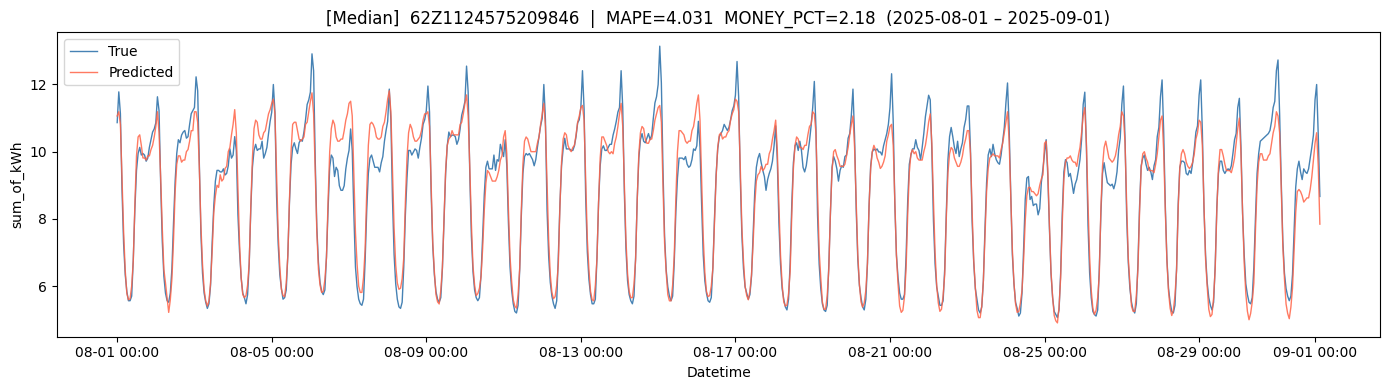

In [92]:
median  = test_station_metrics.iloc[198][GROUP_COL]

plot_forecast(test_eval, eic_code=median,  title_prefix="[Median]  ")

## Inference example — single station, single forecast call

Quick sanity-check of the pipeline interface for one station and the next
`PREDICTION_LEN` hours, with all covariates supplied.


Station 62Z0008583037334: next 64h forecast (head):
         item_id           timestamp target_name  predictions     0.1     0.5    0.9
62Z0008583037334 2025-07-01 00:00:00      target      21.6250 19.1250 21.6250 24.750
62Z0008583037334 2025-07-01 01:00:00      target      19.0000 16.1250 19.0000 21.625
62Z0008583037334 2025-07-01 02:00:00      target      16.5000 13.8750 16.5000 19.750
62Z0008583037334 2025-07-01 03:00:00      target      15.5000 12.5000 15.5000 18.750
62Z0008583037334 2025-07-01 04:00:00      target      14.5625 11.7500 14.5625 18.000
62Z0008583037334 2025-07-01 05:00:00      target      14.3125 11.8125 14.3125 17.875
62Z0008583037334 2025-07-01 06:00:00      target      14.9375 12.6250 14.9375 18.250
62Z0008583037334 2025-07-01 07:00:00      target      16.5000 13.3750 16.5000 20.125


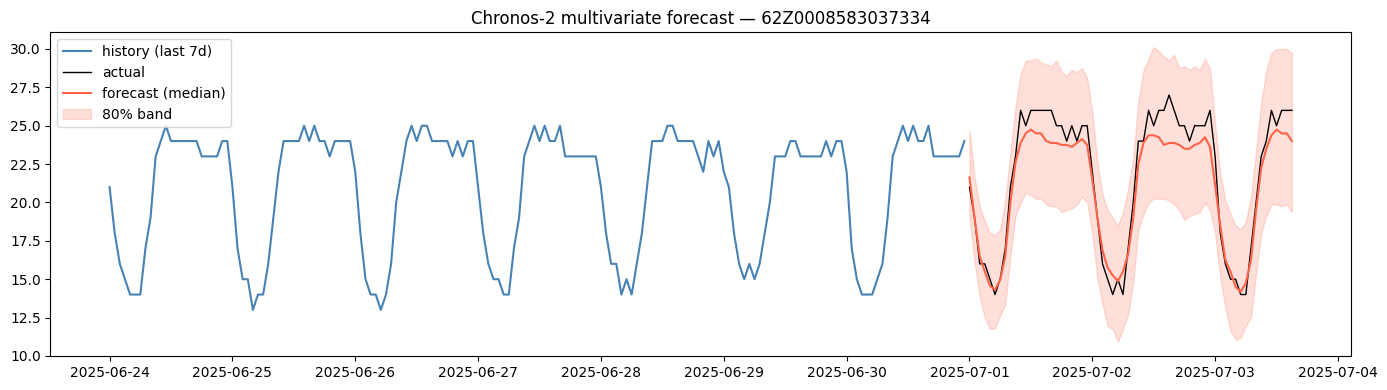

In [91]:
example_code = usable_codes[0]

# Build a single (context, future) pair for this one station
ctx_one = train_hist_by_code[example_code].tail(CONTEXT_LEN)
fut_one = val_hist_by_code[example_code].head(PREDICTION_LEN)

ctx_long_one = _rename_for_chronos(ctx_one, drop_target=False)
fut_long_one = _rename_for_chronos(fut_one, drop_target=True)

pred_one = pipeline.predict_df(
    ctx_long_one,
    future_df=fut_long_one,
    prediction_length=PREDICTION_LEN,
    quantile_levels=QUANTILE_LEVELS,
    id_column=CHRONOS_ID_COL,
    timestamp_column=CHRONOS_TS_COL,
    target=CHRONOS_TGT_COL,
)

print(f"Station {example_code}: next {PREDICTION_LEN}h forecast (head):")
print(pred_one.head(8).to_string(index=False))

# Plot it
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ctx_one["datetime"].tail(168), ctx_one[Y_COL].tail(168), color="steelblue", label="history (last 7d)")
ax.plot(fut_one["datetime"], fut_one[Y_COL], color="black", linewidth=1, label="actual")
# pick the median column
q_cols = [c for c in pred_one.columns if str(c) not in {CHRONOS_ID_COL, CHRONOS_TS_COL}]
if "0.5" in q_cols:
    median_col = "0.5"
else:
    median_col = next((c for c in q_cols if str(c) == "0.5"), q_cols[len(q_cols)//2])
ax.plot(pred_one[CHRONOS_TS_COL], pred_one[median_col], color="tomato", label="forecast (median)")
if "0.1" in pred_one.columns and "0.9" in pred_one.columns:
    ax.fill_between(pred_one[CHRONOS_TS_COL], pred_one["0.1"], pred_one["0.9"],
                    color="tomato", alpha=0.2, label="80% band")
ax.legend(); ax.set_title(f"Chronos-2 multivariate forecast — {example_code}")
plt.tight_layout(); plt.show()
